<a href="https://colab.research.google.com/github/shubhmittal-627/ShubhMittal-Cognitive-Computing-UCS420-/blob/main/assignment(7).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ques1


In [2]:
import string
import nltk
import pandas as pd
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords


nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))

def process_ticket(text):
    sentences = sent_tokenize(text)
    num_sentences = len(sentences)

    tokens = word_tokenize(text)
    num_tokens = len(tokens)


    punct_tokens = [t for t in tokens if t in string.punctuation]
    num_punct = len(punct_tokens)

    stopword_tokens = [t for t in tokens if t.lower() in stop_words and t not in string.punctuation]
    num_stopwords = len(stopword_tokens)

    final_tokens = [t for t in tokens if t not in string.punctuation and t.lower() not in stop_words]
    num_final = len(final_tokens)

    num_unique = len(set(tokens))

    stats = {
        'num_sentences': num_sentences,
        'num_tokens': num_tokens,
        'num_punctuation': num_punct,
        'num_stopwords': num_stopwords,
        'num_unique_tokens': num_unique,
        'num_final_tokens': num_final
    }

    details = {
        'tokens': tokens,
        'punctuation_tokens': punct_tokens,
        'stopword_tokens': stopword_tokens,
        'final_tokens': final_tokens
    }

    return stats, details


tickets = [
    "Hello! My router isn't working at 192.168.1.1. Contact me at user@test.com or 555-123-4567.",
    "State-of-the-art Wi-Fi system version 2.0.1 is down. Price was $95.5.",
    "Urgent response needed. An Apple a day keeps issues away!"
]


rows = []
details_list = []

for t in tickets:
    stats, details = process_ticket(t)
    rows.append(stats)
    details_list.append(details)

df_tickets = pd.DataFrame(rows)


total_row = df_tickets.sum(axis=0)
total_row.name = 'Total'
df_tickets_with_total = pd.concat([df_tickets, pd.DataFrame(total_row).T])

print("--- Preprocessing Summary Table ---")
print(df_tickets_with_total)


selected_ticket_index = 0
print(f"\n--- Detailed Tokens for Ticket {selected_ticket_index} ---")
print("Actual Tokens:", details_list[selected_ticket_index]['tokens'])
print("Punctuation Tokens:", details_list[selected_ticket_index]['punctuation_tokens'])
print("Stopwords Tokens:", details_list[selected_ticket_index]['stopword_tokens'])
print("Final Tokens:", details_list[selected_ticket_index]['final_tokens'])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


--- Preprocessing Summary Table ---
       num_sentences  num_tokens  num_punctuation  num_stopwords  \
0                  3          19                4              6   
1                  2          13                3              3   
2                  2          12                2              2   
Total              7          44                9             11   

       num_unique_tokens  num_final_tokens  
0                     17                 9  
1                     12                 7  
2                     12                 8  
Total                 41                24  

--- Detailed Tokens for Ticket 0 ---
Actual Tokens: ['Hello', '!', 'My', 'router', 'is', "n't", 'working', 'at', '192.168.1.1', '.', 'Contact', 'me', 'at', 'user', '@', 'test.com', 'or', '555-123-4567', '.']
Punctuation Tokens: ['!', '.', '@', '.']
Stopwords Tokens: ['My', 'is', 'at', 'me', 'at', 'or']
Final Tokens: ['Hello', 'router', "n't", 'working', '192.168.1.1', 'Contact', 'user', 'test.c

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


ques2

In [3]:
import re

TEST_LINES = [
    "Contact support@domain.org or visit https://example.com for assistance.",
    "Call 123-456-7890 or 987.654.3210 today. Version 2.0.1 update costs 95.5 USD.",
    "An Apple isn't state-of-the-art Wi-Fi, but state_of_the_art works."
]

print("--- 2a. Extraction ---")
for idx, text in enumerate(TEST_LINES):
    print(f"\nLine {idx+1}: {text}")

    w_gt_5 = re.findall(r'\b[A-Za-z]{6,}\b', text)

    numbers = re.findall(r'\b\d+(?:\.\d+)*\b', text)

    cap_words = re.findall(r'\b[A-Z][a-z]*\b', text)

    vowel_words = re.findall(r'\b[aeiouAEIOU][a-zA-Z]*\b', text)

    print(" > Words > 5 letters:", w_gt_5)
    print(" > Numbers (inc. decimals/versions):", numbers)
    print(" > Capitalized words:", cap_words)
    print(" > Vowel-starting words:", vowel_words)

print("\n--- 2b. Replacement ---")
for idx, text in enumerate(TEST_LINES):

    email_pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b'
    url_pattern = r'https?://[^\s]+|www\.[^\s]+'
    phone_pattern = r'\b(?:\+?\d{1,3}[-.\s]?)?\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}\b'

    replaced = re.sub(email_pattern, '<EMAIL>', text)
    replaced = re.sub(url_pattern, '<URL>', replaced)
    replaced = re.sub(phone_pattern, '<PHONE>', replaced)

    print(f"Line {idx+1} Replaced: {replaced}")

--- 2a. Extraction ---

Line 1: Contact support@domain.org or visit https://example.com for assistance.
 > Words > 5 letters: ['Contact', 'support', 'domain', 'example', 'assistance']
 > Numbers (inc. decimals/versions): []
 > Capitalized words: ['Contact']
 > Vowel-starting words: ['org', 'or', 'example', 'assistance']

Line 2: Call 123-456-7890 or 987.654.3210 today. Version 2.0.1 update costs 95.5 USD.
 > Words > 5 letters: ['Version', 'update']
 > Numbers (inc. decimals/versions): ['123', '456', '7890', '987.654.3210', '2.0.1', '95.5']
 > Capitalized words: ['Call', 'Version']
 > Vowel-starting words: ['or', 'update', 'USD']

Line 3: An Apple isn't state-of-the-art Wi-Fi, but state_of_the_art works.
 > Words > 5 letters: []
 > Numbers (inc. decimals/versions): []
 > Capitalized words: ['An', 'Apple', 'Wi', 'Fi']
 > Vowel-starting words: ['An', 'Apple', 'isn', 'of', 'art']

--- 2b. Replacement ---
Line 1 Replaced: Contact <EMAIL> or visit <URL> for assistance.
Line 2 Replaced: Call 

ques 3

In [5]:
from nltk.tokenize import RegexpTokenizer


custom_pattern = r'''(?x)
      [A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,} # Emails
    | https?://[^\s]+|www\.[^\s]+                     # URLs
    | \b(?:\+?\d{1,3}[-.\s]?)?\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}\b # Phone numbers
    | \b\d+(?:\.\d+)+\b                               # Versions / Decimals (e.g., 2.0.1, 95.5)
    | \b[A-Za-z]+(?:-[A-Za-z]+)+\b                    # Hyphenated words (e.g., Wi-Fi, state-of-the-art)
    | \b[A-Za-z]+'[a-zA-Z]+\b                         # Contractions (e.g., isn't)
    | \w+                                             # Other words
    | [^\s\w]                                         # Single punctuation characters
'''

tokenizer = RegexpTokenizer(custom_pattern)

def my_tokenize(text):
    return tokenizer.tokenize(text)

# Test and compare
for text in TEST_LINES:
    my_toks = my_tokenize(text)
    nltk_toks = word_tokenize(text)

    print(f"\nText: {text}")
    print("my_tokenize:   ", my_toks)
    print("word_tokenize: ", nltk_toks)





Text: Contact support@domain.org or visit https://example.com for assistance.
my_tokenize:    ['Contact', 'support@domain.org', 'or', 'visit', 'https://example.com', 'for', 'assistance', '.']
word_tokenize:  ['Contact', 'support', '@', 'domain.org', 'or', 'visit', 'https', ':', '//example.com', 'for', 'assistance', '.']

Text: Call 123-456-7890 or 987.654.3210 today. Version 2.0.1 update costs 95.5 USD.
my_tokenize:    ['Call', '123-456-7890', 'or', '987.654.3210', 'today', '.', 'Version', '2.0.1', 'update', 'costs', '95.5', 'USD', '.']
word_tokenize:  ['Call', '123-456-7890', 'or', '987.654.3210', 'today', '.', 'Version', '2.0.1', 'update', 'costs', '95.5', 'USD', '.']

Text: An Apple isn't state-of-the-art Wi-Fi, but state_of_the_art works.
my_tokenize:    ['An', 'Apple', "isn't", 'state-of-the-art', 'Wi-Fi', ',', 'but', 'state_of_the_art', 'works', '.']
word_tokenize:  ['An', 'Apple', 'is', "n't", 'state-of-the-art', 'Wi-Fi', ',', 'but', 'state_of_the_art', 'works', '.']


In [ ]:
ques 4

In [7]:
from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer, WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

# Initialize stemmers and lemmatizer
porter = PorterStemmer()
lancaster = LancasterStemmer()
# Custom RegexpStemmer choosing 'ing$' based on words like 'working', 'testing'
regexp_stemmer = RegexpStemmer('ing$', min=4)
lemmatizer = WordNetLemmatizer()

# Helper to map NLTK POS tags to WordNet POS tags
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

# Gather unique final tokens across tickets
all_final_tokens = set()
for t in tickets:
    _, details = process_ticket(t)
    all_final_tokens.update(details['final_tokens'])

unique_tokens = sorted(list(all_final_tokens))

# Perform POS tagging
pos_tags = dict(pos_tag(unique_tokens))

comparison_data = []
differing_data = []

for token in unique_tokens:
    p_stem = porter.stem(token)
    l_stem = lancaster.stem(token)
    r_stem = regexp_stemmer.stem(token)

    wn_pos = get_wordnet_pos(pos_tags[token])
    lemma = lemmatizer.lemmatize(token, pos=wn_pos)

    row = {
        'Token': token,
        'Porter': p_stem,
        'Lancaster': l_stem,
        'Regexp': r_stem,
        'WordNet_Lemma': lemma
    }
    comparison_data.append(row)

    # Check if outputs differ across methods
    if len({p_stem, l_stem, r_stem, lemma}) > 1:
        differing_data.append(row)

df_differing = pd.DataFrame(differing_data)

print("--- Differing Stemming/Lemmatization Results ---")
print(df_differing)



--- Differing Stemming/Lemmatization Results ---
               Token            Porter         Lancaster            Regexp  \
0              Apple              appl              appl             Apple   
1            Contact           contact           contact           Contact   
2              Hello             hello             hello             Hello   
3              Price             price              pric             Price   
4   State-of-the-art  state-of-the-art  state-of-the-art  State-of-the-art   
5             Urgent            urgent               urg            Urgent   
6              Wi-Fi             wi-fi              wi-f             Wi-Fi   
7             issues              issu              issu            issues   
8              keeps              keep              keep             keeps   
9             needed              need               nee            needed   
10          response           respons           respons          response   
11            r

ques 5

--- Corpus Statistics ---
                     Total Tokens  Unique Tokens       TTR
S1 (All Tokens)              44.0           37.0  0.840909
S2 (No Punctuation)          35.0           33.0  0.942857
S3 (Final Tokens)            24.0           24.0  1.000000
S4 (Porter Stemmed)          24.0           24.0  1.000000

Top 10 words in S1: [('.', 5), ('!', 2), ('is', 2), ('at', 2), ('Hello', 1), ('My', 1), ('router', 1), ("n't", 1), ('working', 1), ('192.168.1.1', 1)]
Top 10 words in S3: [('Hello', 1), ('router', 1), ("n't", 1), ('working', 1), ('192.168.1.1', 1), ('Contact', 1), ('user', 1), ('test.com', 1), ('555-123-4567', 1), ('State-of-the-art', 1)]


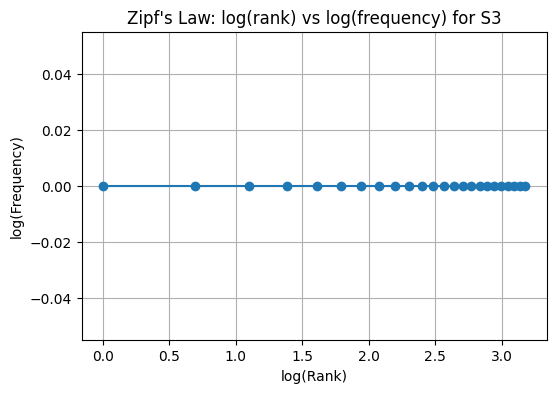


Top 5 Bigrams in S1: [(('Hello', '!'), 1), (('!', 'My'), 1), (('My', 'router'), 1), (('router', 'is'), 1), (('is', "n't"), 1)]
Top 5 Bigrams in S3: [(('Hello', 'router'), 1), (('router', "n't"), 1), (("n't", 'working'), 1), (('working', '192.168.1.1'), 1), (('192.168.1.1', 'Contact'), 1)]


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from nltk.util import ngrams

# Define Sets for the entire corpus
corpus_text = " ".join(tickets)

# S1: all tokens
S1 = word_tokenize(corpus_text)

# S2: tokens without punctuation
S2 = [t for t in S1 if t not in string.punctuation]

# S3: final tokens (no punctuation, no stopwords)
S3 = [t for t in S2 if t.lower() not in stop_words]

# S4: S3 after Porter stemming
S4 = [porter.stem(t) for t in S3]

# Statistics Calculation Function
def calc_stats(tokens):
    tot = len(tokens)
    uniq = len(set(tokens))
    ttr = uniq / tot if tot > 0 else 0
    return tot, uniq, ttr

stats_dict = {
    'S1 (All Tokens)': calc_stats(S1),
    'S2 (No Punctuation)': calc_stats(S2),
    'S3 (Final Tokens)': calc_stats(S3),
    'S4 (Porter Stemmed)': calc_stats(S4),
}

df_stats = pd.DataFrame(stats_dict, index=['Total Tokens', 'Unique Tokens', 'TTR']).T
print("--- Corpus Statistics ---")
print(df_stats)

# 1. Top 10 words of S1 and S3
print("\nTop 10 words in S1:", Counter(S1).most_common(10))
print("Top 10 words in S3:", Counter(S3).most_common(10))

# 2. Plot log(rank) vs log(frequency) for S3
s3_counts = Counter(S3).most_common()
freqs = [count for _, count in s3_counts]
ranks = np.arange(1, len(freqs) + 1)

plt.figure(figsize=(6, 4))
plt.plot(np.log(ranks), np.log(freqs), marker='o', linestyle='-')
plt.xlabel('log(Rank)')
plt.ylabel('log(Frequency)')
plt.title('Zipf\'s Law: log(rank) vs log(frequency) for S3')
plt.grid(True)
plt.show()

# 3. Top 5 bigrams of S1 and S3
s1_bigrams = list(ngrams(S1, 2))
s3_bigrams = list(ngrams(S3, 2))

print("\nTop 5 Bigrams in S1:", Counter(s1_bigrams).most_common(5))
print("Top 5 Bigrams in S3:", Counter(s3_bigrams).most_common(5))

ques 6